# § 0  Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import os
import pickle
from scipy.ndimage import gaussian_filter1d
from scipy.integrate import cumtrapz
import warnings

# Optional: only needed for training cells, not for analysis/reading results
try:
    from pysindy import SINDy, PolynomialLibrary
    from pysindy.optimizers import SR3, STLSQ
except Exception as e:
    SINDy = None
    PolynomialLibrary = None
    SR3 = None
    STLSQ = None
    print(f"[info] pysindy not available for training cells: {e}")

try:
    from sklearn.linear_model import Lasso
except Exception as e:
    Lasso = None
    print(f"[info] sklearn not available for training cells: {e}")

# ignore warnings for cleaner output
#warnings.filterwarnings("ignore")

c:\ProjectSINDyRL\test_sindy\test_sindy\SINDy\SINDy_SK\.venv\Lib\site-packages\pysindy\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


---
# § 1  Main Analysis — `sindy_results_try_*`

> **Main result entry point.** Scans `sindy_results_try_lasso_sr3/` and `sindy_results_try_stlsq/` result directories, aggregates all pkl files, and writes the following CSVs:
> - `stable_rmse_summary_try.csv`: RMSE / Stability summary per (RunTag, Optimizer, Config)
> - `best_config_by_optimizer_try.csv`: Best config per (RunTag, OptimizerGroup)
> - `best_config_by_optimizer_grouped_try.csv`: Best configs grouped by RunTag
>
> **All downstream cells prefer in-memory variables and fall back to these CSVs automatically — no need to re-run this section after the first execution.**

In [2]:
# ==================================================
# Analysis: load local TRY results (no re-training)
# Reports ONLY best config per optimizer (and SR3 l0/l1/l2) per RunTag
# Based on mean stable RMSE across all chunks
# ==================================================

import numpy as np
import pandas as pd
import pickle
from pathlib import Path
import re

BASE_DIR = Path.cwd()
RESULT_DIRS = {
    "try_lasso_sr3": BASE_DIR / "sindy_results_try_lasso_sr3",
    "try_stlsq": BASE_DIR / "sindy_results_try_stlsq",
}
OPT_RE = re.compile(r"_(Lasso|SR3|STLSQ)_")
CHUNK_RE = re.compile(r"chunk_(\d+)")
TAG_RE = re.compile(r"^result_(.+)_(Lasso|SR3|STLSQ)_chunk_\d+$")

def _parse_filename(stem: str):
    """Parse things like:
    - result_n2_Lasso_chunk_123.pkl -> tag=n2 opt=Lasso chunk=123
    - result_n2withfourier1_SR3_chunk_9021.pkl -> tag=n2withfourier1 opt=SR3 chunk=9021
    """
    m_chunk = CHUNK_RE.search(stem)
    chunk_id = int(m_chunk.group(1)) if m_chunk else None

    m_opt = OPT_RE.search(stem)
    opt = m_opt.group(1) if m_opt else "UNKNOWN"

    m_tag = TAG_RE.match(stem)
    tag = m_tag.group(1) if m_tag else ""
    return opt, chunk_id, tag

def _sr3_variant_from_config(config_key: str) -> str | None:
    if not isinstance(config_key, str):
        return None
    ck = config_key.lower()
    # Common encodings we’ve seen: l0 / l1 / l2 as literal substrings
    for v in ("l0", "l1", "l2"):
        if v in ck:
            return v
    return None

rows = []
load_failures = 0
for source_name, result_dir in RESULT_DIRS.items():
    if not result_dir.exists():
        print(f"[warn] Missing folder: {result_dir} (skipping)")
        continue
    
    pkl_files = sorted(result_dir.glob("*.pkl"))
    print(f"[info] {source_name}: {len(pkl_files)} pkl files")
    
    for p in pkl_files:
        opt_name, chunk_id, run_tag = _parse_filename(p.stem)
        try:
            with p.open("rb") as f:
                chunk_res = pickle.load(f)
        except Exception:
            load_failures += 1
            continue
        
        for config_key, res_data in (chunk_res or {}).items():
            rmse = res_data.get("rmse", np.nan)
            if rmse is None or (isinstance(rmse, float) and np.isnan(rmse)):
                continue
            is_unstable = bool(res_data.get("is_unstable", False))
            rows.append({
                "Source": source_name,
                "RunTag": run_tag,
                "Optimizer": opt_name,
                "Config": config_key,
                "Chunk": chunk_id,
                "RMSE": float(rmse),
                "Stable": (not is_unstable),
            })

if load_failures:
    print(f"[warn] Failed to load {load_failures} pickle files (skipped)")

df_results_try = pd.DataFrame(rows)
print(f"[info] Loaded {len(df_results_try)} rows")
display(df_results_try.head())

if df_results_try.empty:
    print("No results loaded. Check that the result folders contain .pkl files.")
else:
    group_cols = ["Source", "RunTag", "Optimizer", "Config"]
    
    # Aggregate across all chunks
    agg_all = df_results_try.groupby(group_cols, dropna=False).agg(
    	Mean_RMSE_All=("RMSE", "mean"),
        Num_Chunks=("Chunk", "count"),
        Unstable_Chunks=("Stable", lambda s: int((~s).sum())),
    ).reset_index()
    
    # Aggregate stable-only chunks
    df_stable = df_results_try[df_results_try["Stable"] == True]
    agg_stable = df_stable.groupby(group_cols, dropna=False).agg(
        Mean_RMSE_Stable=("RMSE", "mean"),
        Std_RMSE_Stable=("RMSE", "std"),
        Stable_Chunks=("Chunk", "count"),
    ).reset_index()
    
    summary_try = pd.merge(agg_all, agg_stable, on=group_cols, how="left")
    summary_try["Stable_Chunks"] = summary_try["Stable_Chunks"].fillna(0).astype(int)
    summary_try["Stability_Fraction"] = summary_try["Stable_Chunks"] / summary_try["Num_Chunks"]
    summary_try["Warning_Count"] = summary_try["Unstable_Chunks"].astype(int)
    
    # Create an optimizer grouping so SR3 can be reported as l0/l1/l2 when encoded in config keys
    def _optimizer_group(row) -> str:
        opt = row["Optimizer"]
        if opt != "SR3":
            return str(opt)
        v = _sr3_variant_from_config(row["Config"])
        return f"SR3_{v}" if v else "SR3"
    
    summary_try["OptimizerGroup"] = summary_try.apply(_optimizer_group, axis=1)
    
    # Select best config per (Source, RunTag, OptimizerGroup) by lowest mean stable RMSE
    # IMPORTANT: exclude configs with zero stable chunks (Mean_RMSE_Stable is NaN)
    candidates = summary_try[summary_try["Stable_Chunks"] > 0].copy()
    candidates = candidates.sort_values(
        by=["Source", "RunTag", "OptimizerGroup", "Mean_RMSE_Stable", "Warning_Count", "Stability_Fraction"],
        ascending=[True, True, True, True, True, False],
    )
    best_by_optimizer = candidates.groupby(["Source", "RunTag", "OptimizerGroup"], as_index=False).head(1)
    best_by_optimizer = best_by_optimizer.sort_values(["Source", "RunTag", "OptimizerGroup"]).reset_index(drop=True)
    
    cols_out = [
        "Source", "RunTag", "OptimizerGroup", "Config",
        "Mean_RMSE_Stable", "Stability_Fraction", "Warning_Count",
        "Stable_Chunks", "Unstable_Chunks", "Num_Chunks",
    ]
    print("\n===== Best config per optimizer (TRY results) =====")
    display(best_by_optimizer[cols_out])
    
    out_best = BASE_DIR / "best_config_by_optimizer_try.csv"
    best_by_optimizer[cols_out].to_csv(out_best, index=False)
    print(f"[info] Wrote: {out_best}")
    
    # Optional: still write the full summary for offline inspection (no notebook display)
    out_full = BASE_DIR / "stable_rmse_summary_try.csv"
    summary_try.sort_values(
        by=["Source", "RunTag", "OptimizerGroup", "Mean_RMSE_Stable"],
        ascending=[True, True, True, True],
    ).to_csv(out_full, index=False)
    print(f"[info] Wrote: {out_full}")

[info] try_lasso_sr3: 66240 pkl files
[info] try_stlsq: 33120 pkl files
[info] Loaded 9709180 rows


,Source,RunTag,Optimizer,Config,Chunk,RMSE,Stable
0,try_lasso_sr3,n2,Lasso,alpha_1e-03_tol_1e-06,0,0.134114,False
1,try_lasso_sr3,n2,Lasso,alpha_1e-03_tol_1e-07,0,0.134114,False
2,try_lasso_sr3,n2,Lasso,alpha_1e-04_tol_1e-06,0,0.006660,True
3,try_lasso_sr3,n2,Lasso,alpha_1e-04_tol_1e-07,0,0.006660,True
4,try_lasso_sr3,n2,Lasso,alpha_1e-05_tol_1e-06,0,0.001688,True



===== Best config per optimizer (TRY results) =====


,Source,RunTag,OptimizerGroup,Config,Mean_RMSE_Stable,Stability_Fraction,Warning_Count,Stable_Chunks,Unstable_Chunks,Num_Chunks
0,try_lasso_sr3,n2,Lasso,alpha_1e-09_tol_1e-07,0.015537,0.673462,3572,7367,3572,10939
1,try_lasso_sr3,n2,SR3_l0,L0_thr_1e-10_nu_1.0_tol_1e-06,0.015551,0.672548,3582,7357,3582,10939
2,try_lasso_sr3,n2,SR3_l1,L1_thr_1e-10_nu_1.0_tol_1e-06,0.015551,0.672548,3582,7357,3582,10939
3,try_lasso_sr3,n2,SR3_l2,L2_thr_1e-05_nu_0.001_tol_1e-07,0.015476,0.672639,3581,7358,3581,10939
4,try_lasso_sr3,n2withfourier1,Lasso,alpha_1e-06_tol_1e-07,0.016041,0.814334,2031,8908,2031,10939
5,try_lasso_sr3,n2withfourier1,SR3_l0,L0_thr_1e-08_nu_0.001_tol_1e-06,0.021896,0.661121,3707,7232,3707,10939
6,try_lasso_sr3,n2withfourier1,SR3_l1,L1_thr_1e-08_nu_0.1_tol_1e-06,0.021896,0.661121,3707,7232,3707,10939
7,try_lasso_sr3,n2withfourier1,SR3_l2,L2_thr_1e-06_nu_0.1_tol_1e-06,0.021895,0.666971,3643,7296,3643,10939
8,try_lasso_sr3,n3,Lasso,alpha_1e-06_tol_1e-06,0.010082,0.585794,4531,6408,4531,10939
9,try_lasso_sr3,n3,SR3_l0,L0_thr_1e-08_nu_0.1_tol_1e-07,0.020215,0.511838,5340,5599,5340,10939


[info] Wrote: c:\ProjectSINDyRL\test_sindy\test_sindy\SINDy\SINDy_SK\best_config_by_optimizer_try.csv
[info] Wrote: c:\ProjectSINDyRL\test_sindy\test_sindy\SINDy\SINDy_SK\stable_rmse_summary_try.csv


In [3]:
# Present best configs grouped by RunTag (n2 -> n2withfourier1 -> n3)
from pathlib import Path
import pandas as pd

# Prefer in-memory variable from the analysis cell; fall back to CSV if needed
if "best_by_optimizer" in globals() and isinstance(best_by_optimizer, pd.DataFrame) and not best_by_optimizer.empty:
    best = best_by_optimizer.copy()
else:
    p = Path.cwd() / "best_config_by_optimizer_try.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing {p}. Run the analysis cell first.")
    best = pd.read_csv(p)

# Desired RunTag ordering
run_order = ["n2", "n2withfourier1", "n3"]
best["_run_order"] = best["RunTag"].apply(lambda x: run_order.index(x) if x in run_order else 999)

# Desired optimizer ordering within each RunTag
opt_order = ["Lasso", "STLSQ", "SR3_l0", "SR3_l1", "SR3_l2", "SR3"]
best["_opt_order"] = best["OptimizerGroup"].apply(lambda x: opt_order.index(x) if x in opt_order else 999)

# If the same OptimizerGroup appears from multiple sources, keep the best one (lowest stable RMSE)
best = best.sort_values(["_run_order", "RunTag", "_opt_order", "Mean_RMSE_Stable"]).groupby(
    ["RunTag", "OptimizerGroup"], as_index=False
).head(1)

cols_out = [
    "RunTag", "OptimizerGroup", "Config",
    "Mean_RMSE_Stable", "Stability_Fraction", "Warning_Count",
    "Stable_Chunks", "Unstable_Chunks", "Num_Chunks",
    "Source",
]

best_sorted = best.sort_values(["_run_order", "RunTag", "_opt_order", "OptimizerGroup"]).reset_index(drop=True)

print("===== Best config per optimizer (grouped by RunTag) =====")
for rt, sub in best_sorted.groupby(["RunTag"], sort=False):
    print(f"\n--- {rt} ---")
    sub_sorted = sub.sort_values(["_opt_order", "OptimizerGroup"])
    display(sub_sorted[cols_out])

# cleanup helper columns in case you keep using `best_sorted` later
best_sorted = best_sorted.drop(columns=["_run_order", "_opt_order"], errors="ignore")

# Optional: write the best configs grouped by RunTag to a separate CSV
#out_grouped = BASE_DIR / "best_config_by_optimizer_grouped_try.csv"
#best_sorted[cols_out].to_csv(out_grouped, index=False)
#print(f"[info] Wrote: {out_grouped}")

===== Best config per optimizer (grouped by RunTag) =====

--- ('n2',) ---


,RunTag,OptimizerGroup,Config,Mean_RMSE_Stable,Stability_Fraction,Warning_Count,Stable_Chunks,Unstable_Chunks,Num_Chunks,Source
0,n2,Lasso,alpha_1e-09_tol_1e-07,0.015537,0.673462,3572,7367,3572,10939,try_lasso_sr3
1,n2,STLSQ,thr_1e-09_alpha_1e+01,0.015461,0.673462,3572,7367,3572,10939,try_stlsq
2,n2,SR3_l0,L0_thr_1e-10_nu_1.0_tol_1e-06,0.015551,0.672548,3582,7357,3582,10939,try_lasso_sr3
3,n2,SR3_l1,L1_thr_1e-10_nu_1.0_tol_1e-06,0.015551,0.672548,3582,7357,3582,10939,try_lasso_sr3
4,n2,SR3_l2,L2_thr_1e-05_nu_0.001_tol_1e-07,0.015476,0.672639,3581,7358,3581,10939,try_lasso_sr3



--- ('n2withfourier1',) ---


,RunTag,OptimizerGroup,Config,Mean_RMSE_Stable,Stability_Fraction,Warning_Count,Stable_Chunks,Unstable_Chunks,Num_Chunks,Source
5,n2withfourier1,Lasso,alpha_1e-06_tol_1e-07,0.016041,0.814334,2031,8908,2031,10939,try_lasso_sr3
6,n2withfourier1,STLSQ,thr_1e-08_alpha_1e-02,0.021785,0.670628,3603,7336,3603,10939,try_stlsq
7,n2withfourier1,SR3_l0,L0_thr_1e-08_nu_0.001_tol_1e-06,0.021896,0.661121,3707,7232,3707,10939,try_lasso_sr3
8,n2withfourier1,SR3_l1,L1_thr_1e-08_nu_0.1_tol_1e-06,0.021896,0.661121,3707,7232,3707,10939,try_lasso_sr3
9,n2withfourier1,SR3_l2,L2_thr_1e-06_nu_0.1_tol_1e-06,0.021895,0.666971,3643,7296,3643,10939,try_lasso_sr3



--- ('n3',) ---


...

,RunTag,OptimizerGroup,Config,Mean_RMSE_Stable,Stability_Fraction,Warning_Count,Stable_Chunks,Unstable_Chunks,Num_Chunks,Source
0,n2,Lasso,alpha_1e-09_tol_1e-07,0.015537,0.673462,3572,7367,3572,10939,try_lasso_sr3
1,n2,STLSQ,thr_1e-09_alpha_1e+01,0.015461,0.673462,3572,7367,3572,10939,try_stlsq
2,n2,SR3_l0,L0_thr_1e-10_nu_1.0_tol_1e-06,0.015551,0.672548,3582,7357,3582,10939,try_lasso_sr3
3,n2,SR3_l1,L1_thr_1e-10_nu_1.0_tol_1e-06,0.015551,0.672548,3582,7357,3582,10939,try_lasso_sr3
4,n2,SR3_l2,L2_thr_1e-05_nu_0.001_tol_1e-07,0.015476,0.672639,3581,7358,3581,10939,try_lasso_sr3



--- ('n2withfourier1',) ---


,RunTag,OptimizerGroup,Config,Mean_RMSE_Stable,Stability_Fraction,Warning_Count,Stable_Chunks,Unstable_Chunks,Num_Chunks,Source
5,n2withfourier1,Lasso,alpha_1e-06_tol_1e-07,0.016041,0.814334,2031,8908,2031,10939,try_lasso_sr3
6,n2withfourier1,STLSQ,thr_1e-08_alpha_1e-02,0.021785,0.670628,3603,7336,3603,10939,try_stlsq
7,n2withfourier1,SR3_l0,L0_thr_1e-08_nu_0.001_tol_1e-06,0.021896,0.661121,3707,7232,3707,10939,try_lasso_sr3
8,n2withfourier1,SR3_l1,L1_thr_1e-08_nu_0.1_tol_1e-06,0.021896,0.661121,3707,7232,3707,10939,try_lasso_sr3
9,n2withfourier1,SR3_l2,L2_thr_1e-06_nu_0.1_tol_1e-06,0.021895,0.666971,3643,7296,3643,10939,try_lasso_sr3



--- ('n3',) ---


,RunTag,OptimizerGroup,Config,Mean_RMSE_Stable,Stability_Fraction,Warning_Count,Stable_Chunks,Unstable_Chunks,Num_Chunks,Source
10,n3,Lasso,alpha_1e-06_tol_1e-06,0.010082,0.585794,4531,6408,4531,10939,try_lasso_sr3
11,n3,STLSQ,thr_1e-08_alpha_1e+01,0.019266,0.540452,5027,5912,5027,10939,try_stlsq
12,n3,SR3_l0,L0_thr_1e-08_nu_0.1_tol_1e-07,0.020215,0.511838,5340,5599,5340,10939,try_lasso_sr3
13,n3,SR3_l1,L1_thr_1e-07_nu_0.1_tol_1e-06,0.018020,0.512021,5338,5601,5338,10939,try_lasso_sr3
14,n3,SR3_l2,L2_thr_1e-07_nu_0.001_tol_1e-06,0.013946,0.540909,5022,5917,5022,10939,try_lasso_sr3


---
# § 2  n3 Coefficient Inspection

> Extracts the coefficient matrix from pkl files of the best n3 configuration, inspects the ω coefficient in the ω̇ equation, and aggregates its distribution across chunks.

In [4]:
# === n3 omega-in-ωdot heatmap: inspect pickle schema ===
from pathlib import Path
import pickle
import re

best_csv = Path.cwd() / "best_config_by_optimizer_try.csv"
if not best_csv.exists():
    raise FileNotFoundError(f"Missing {best_csv}. Run the TRY analysis cell first.")

best_df = pd.read_csv(best_csv)

# pick overall best configuration for n3 (lowest Mean_RMSE_Stable)
best_n3 = best_df[best_df["RunTag"] == "n3"].sort_values("Mean_RMSE_Stable").head(1)
if best_n3.empty:
    raise ValueError("No n3 rows found in best_config_by_optimizer_try.csv")

row = best_n3.iloc[0].to_dict()
optimizer_group = row["OptimizerGroup"]
optimizer = optimizer_group.split("_")[0]  # SR3_l0 -> SR3
source_name = row["Source"]
config_key = row["Config"]

result_dir = Path.cwd() / ("sindy_results_try_lasso_sr3" if source_name == "try_lasso_sr3" else "sindy_results_try_stlsq")

pattern = re.compile(rf"^result_n3_{re.escape(optimizer)}_chunk_\d+\.pkl$")
files = [p for p in result_dir.glob("*.pkl") if pattern.match(p.name)]
if not files:
    raise FileNotFoundError(f"No files found for pattern {pattern.pattern} in {result_dir}")

# Find first file that contains this config_key
sample_path = None
sample_data = None
for p in sorted(files)[:500]:  # cap for quick discovery; increase if needed
    with p.open("rb") as f:
        d = pickle.load(f)
    if isinstance(d, dict) and config_key in d:
        sample_path = p
        sample_data = d[config_key]
        break

if sample_path is None:
    raise ValueError(
        "Could not find the chosen n3 config_key in the first 500 chunk pickles. "
        "Increase the search cap or re-run analysis to confirm config selection."
    )

coef = sample_data.get("coefficients") if isinstance(sample_data, dict) else None

print("[n3 best]", {"OptimizerGroup": optimizer_group, "Source": source_name, "Optimizer": optimizer, "Config": config_key})
print("[sample pickle]", sample_path.name)
print("[sample res_data keys]", sorted(sample_data.keys()) if isinstance(sample_data, dict) else type(sample_data))
print("[coef shape]", getattr(coef, "shape", None), "dtype=", getattr(coef, "dtype", None))

# also print shallow structure hints for equation storage
for k in ["model", "sindy_model", "sindy", "equations", "eqs", "coefficients", "coef", "feature_names", "library_feature_names"]:
    if isinstance(sample_data, dict) and k in sample_data:
        v = sample_data[k]
        print(f"  - {k}: {type(v)}")


[n3 best] {'OptimizerGroup': 'Lasso', 'Source': 'try_lasso_sr3', 'Optimizer': 'Lasso', 'Config': 'alpha_1e-06_tol_1e-06'}
[sample pickle] result_n3_Lasso_chunk_0.pkl
[sample res_data keys] ['coefficients', 'is_unstable', 'rmse', 'warnings']
[coef shape] (3, 20) dtype= float64
  - coefficients: <class 'numpy.ndarray'>


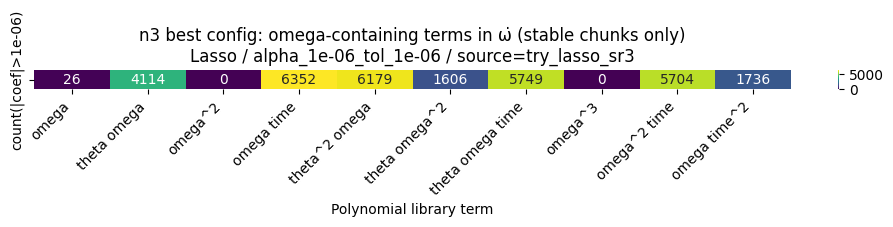

[scan summary] {'result_dir': 'c:\\ProjectSINDyRL\\test_sindy\\test_sindy\\SINDy\\SINDy_SK\\sindy_results_try_lasso_sr3', 'optimizer': 'Lasso', 'poly_degree': 3, 'stable_chunks_used': 6408, 'unstable_chunks_skipped': 4531, 'files_without_config_key': 101}


In [8]:
# === n3 omega-in-ωdot heatmap (counts across chunks) ===
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pysindy as ps

thr = 1e-6  # coefficient magnitude threshold for "term appears"

# infer polynomial degree from RunTag like "n3" -> 3 (fallback to 3)
try:
    poly_degree = int(str(row["RunTag"]).lstrip("n").split("with")[0])
except Exception:
    poly_degree = 3

feature_vars = ["theta", "omega", "time"]
poly_lib = ps.PolynomialLibrary(degree=poly_degree)
poly_lib.fit(np.zeros((1, len(feature_vars))))
all_feature_names = poly_lib.get_feature_names(feature_vars)

omega_term_idxs = [i for i, name in enumerate(all_feature_names) if "omega" in name]
omega_term_names = [all_feature_names[i] for i in omega_term_idxs]

if len(omega_term_idxs) == 0:
    raise ValueError("No polynomial feature names contained 'omega'. Check feature variables.")

# scan all chunk pickles for this optimizer/run/config and count omega-terms in ω̇
chunk_re = re.compile(r"chunk_(\d+)")

term_counts = np.zeros(len(omega_term_idxs), dtype=int)
stable_chunks_seen = 0
unstable_chunks_seen = 0
missing_config_files = 0

for p in sorted(files):
    with p.open("rb") as f:
        d = pickle.load(f)
    if not isinstance(d, dict) or config_key not in d:
        missing_config_files += 1
        continue

    res = d[config_key]
    if not isinstance(res, dict):
        continue

    is_unstable = bool(res.get("is_unstable", False))
    if is_unstable:
        unstable_chunks_seen += 1
        continue

    coef = res.get("coefficients")
    if not isinstance(coef, np.ndarray) or coef.ndim != 2 or coef.shape[0] < 2:
        continue

    stable_chunks_seen += 1
    omega_row = coef[1]  # omega_dot assuming vars=[theta, omega, time]
    present = np.abs(omega_row[omega_term_idxs]) > thr
    term_counts += present.astype(int)

# Heatmap: 1 row with counts per omega-related term
heat = pd.DataFrame([term_counts], index=[f"count(|coef|>{thr:g})"], columns=omega_term_names)

plt.figure(figsize=(max(10, 0.6 * len(omega_term_names)), 2.2))
sns.heatmap(heat, annot=True, fmt="d", cmap="viridis", cbar=True)
plt.title(f"n3 best config: omega-containing terms in ω̇ (stable chunks only)\n{optimizer_group} / {config_key} / source={source_name}")
plt.xlabel("Polynomial library term")
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("[scan summary]", {
    "result_dir": str(result_dir),
    "optimizer": optimizer,
    "poly_degree": poly_degree,
    "stable_chunks_used": stable_chunks_seen,
    "unstable_chunks_skipped": unstable_chunks_seen,
    "files_without_config_key": missing_config_files,
})


---
# § 3  Advanced Analysis Pack

> Requires the CSV files generated in §1 (`stable_rmse_summary_try.csv`, `best_config_by_optimizer_try.csv`).  
> Run the **Common Loader** cell first, then execute any of the following cells independently:


In [5]:
# Common loader for advanced analyses
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path.cwd()

# 1) summary table (preferred in-memory, else CSV)
if "summary_try" in globals() and isinstance(summary_try, pd.DataFrame) and not summary_try.empty:
    summary_adv = summary_try.copy()
else:
    p_summary = BASE_DIR / "stable_rmse_summary_try.csv"
    if not p_summary.exists():
        raise FileNotFoundError(f"Missing {p_summary}. Run analysis cell first.")
    summary_adv = pd.read_csv(p_summary)

# 2) best-by-optimizer table (preferred in-memory, else CSV)
if "best_by_optimizer" in globals() and isinstance(best_by_optimizer, pd.DataFrame) and not best_by_optimizer.empty:
    best_adv = best_by_optimizer.copy()
else:
    p_best = BASE_DIR / "best_config_by_optimizer_try.csv"
    if not p_best.exists():
        raise FileNotFoundError(f"Missing {p_best}. Run analysis cell first.")
    best_adv = pd.read_csv(p_best)



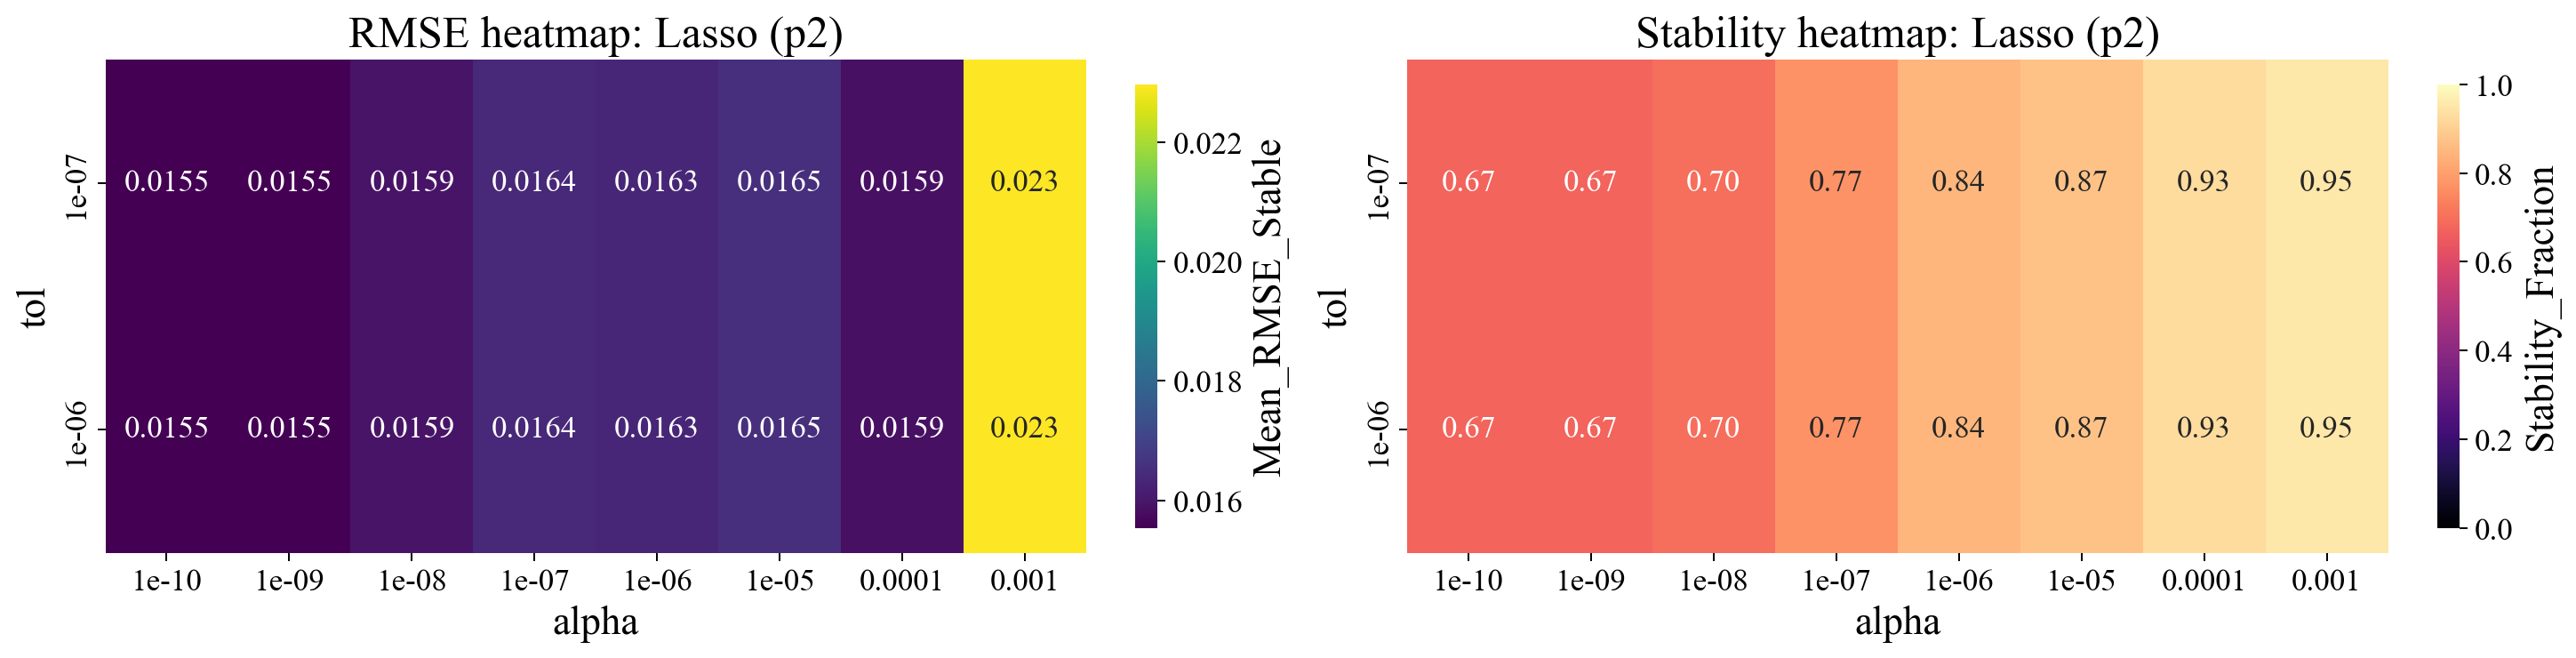

[best RMSE point]     {'p1': 1e-09, 'p2': 1e-07, 'Mean_RMSE_Stable': 0.015537149658905, 'Stability_Fraction': 0.6734619252216839}
[best Stability point] {'p1': 0.001, 'p2': 1e-07, 'Mean_RMSE_Stable': 0.0229730857416855, 'Stability_Fraction': 0.9499040131639088}


In [6]:
# 5) Enhanced heatmaps: RMSE + Stability overlay view

_num_pat = r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?"


def _to_float_safe(x):
    try:
        return float(x)
    except Exception:
        return np.nan


_regex_map = {
    "Lasso": (rf"(?:^|_)alpha_(?P<p1>{_num_pat})(?:_|$)", rf"(?:^|_)tol_(?P<p2>{_num_pat})(?:_|$)", "alpha", "tol"),
    "STLSQ": (rf"(?:^|_)thr_(?P<p1>{_num_pat})(?:_|$)", rf"(?:^|_)alpha_(?P<p2>{_num_pat})(?:_|$)", "thr", "alpha"),
    "SR3": (rf"(?:^|_)nu_(?P<p1>{_num_pat})(?:_|$)", rf"(?:^|_)thr_(?P<p2>{_num_pat})(?:_|$)", "nu", "thr"),
}

_RUN_TAG_LABELS = {
    "n2": "p2",
    "n2withfourier1": "p2f1",
    "n3": "p3",
}


def plot_dual_heatmap(summary_df, run_tag, opt_group):
    """
    Side-by-side RMSE and Stability heatmaps for one RunTag × OptimizerGroup.

    Parameters
    ----------
    summary_df : pd.DataFrame  — full summary table (e.g. summary_adv)
    run_tag    : str           — "n2", "n2withfourier1", or "n3"
    opt_group  : str           — "Lasso", "STLSQ", "SR3", "SR3_l0", "SR3_l1", "SR3_l2"
    """
    # Improve readability and publication quality.
    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "figure.dpi": 180,

    })

    display_tag = _RUN_TAG_LABELS.get(run_tag, run_tag)

    opt_base = "SR3" if str(opt_group).startswith("SR3") else str(opt_group)
    if opt_base not in _regex_map:
        raise ValueError(f"Unsupported opt_group: {opt_group!r}")

    re1, re2, x_name, y_name = _regex_map[opt_base]
    configs = pd.Series(summary_df["Config"].astype(str))

    hm = summary_df.copy()
    hm["p1"] = configs.str.extract(re1)["p1"].map(_to_float_safe).values
    hm["p2"] = configs.str.extract(re2)["p2"].map(_to_float_safe).values
    hm = hm[(hm["RunTag"] == run_tag) & (hm["OptimizerGroup"] == opt_group)].dropna(
        subset=["p1", "p2", "Mean_RMSE_Stable"]
    )

    if hm.empty:
        print(f"[warn] No heatmap rows for RunTag={display_tag!r}, OptimizerGroup={opt_group!r}")
        return

    agg = hm.groupby(["p1", "p2"], as_index=False).agg(
        Mean_RMSE_Stable=("Mean_RMSE_Stable", "min"),
        Stability_Fraction=("Stability_Fraction", "mean"),
        Stable_Chunks=("Stable_Chunks", "sum"),
        Num_Chunks=("Num_Chunks", "sum"),
    )

    x_sorted = sorted(agg["p1"].unique())
    y_sorted = sorted(agg["p2"].unique())
    grid_rmse = agg.pivot(index="p2", columns="p1", values="Mean_RMSE_Stable").reindex(
        index=y_sorted, columns=x_sorted
    )
    grid_stab = agg.pivot(index="p2", columns="p1", values="Stability_Fraction").reindex(
        index=y_sorted, columns=x_sorted
    )

    do_annot = grid_rmse.shape[0] * grid_rmse.shape[1] <= 300
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), constrained_layout=True, dpi=180)

    sns.heatmap(
        grid_rmse,
        ax=axes[0],
        cmap="viridis",
        annot=do_annot,
        fmt=".3g",
        annot_kws={"size": 14},
        #linewidths=0.01,
        linecolor="white",
        cbar_kws={"label": "Mean_RMSE_Stable", "shrink": 0.9},
        mask=grid_rmse.isna(),
    )
    axes[0].set_title(f"RMSE heatmap: {opt_group} ({display_tag})")
    axes[0].set_xlabel(x_name)
    axes[0].set_ylabel(y_name)

    sns.heatmap(
        grid_stab,
        ax=axes[1],
        cmap="magma",
        vmin=0,
        vmax=1,
        annot=do_annot,
        fmt=".2f",
        annot_kws={"size": 14},
        #linewidths=0.3,
        linecolor="white",
        cbar_kws={"label": "Stability_Fraction", "shrink": 0.9},
        mask=grid_stab.isna(),
    )
    axes[1].set_title(f"Stability heatmap: {opt_group} ({display_tag})")
    axes[1].set_xlabel(x_name)
    axes[1].set_ylabel(y_name)

    plt.show()

    best_rmse_idx = agg["Mean_RMSE_Stable"].idxmin()
    best_stab_idx = agg["Stability_Fraction"].idxmax()
    print("[best RMSE point]    ", agg.loc[best_rmse_idx, ["p1", "p2", "Mean_RMSE_Stable", "Stability_Fraction"]].to_dict())
    print("[best Stability point]", agg.loc[best_stab_idx, ["p1", "p2", "Mean_RMSE_Stable", "Stability_Fraction"]].to_dict())


# ── Run ───────────────────────────────────────────────────────────────────────
RUN_TAG_HM = "n2"      # "n2", "n2withfourier1", "n3"
OPT_GROUP_HM = "Lasso"  # "Lasso", "STLSQ", "SR3", "SR3_l0", "SR3_l1", "SR3_l2"

plot_dual_heatmap(summary_adv, RUN_TAG_HM, OPT_GROUP_HM)

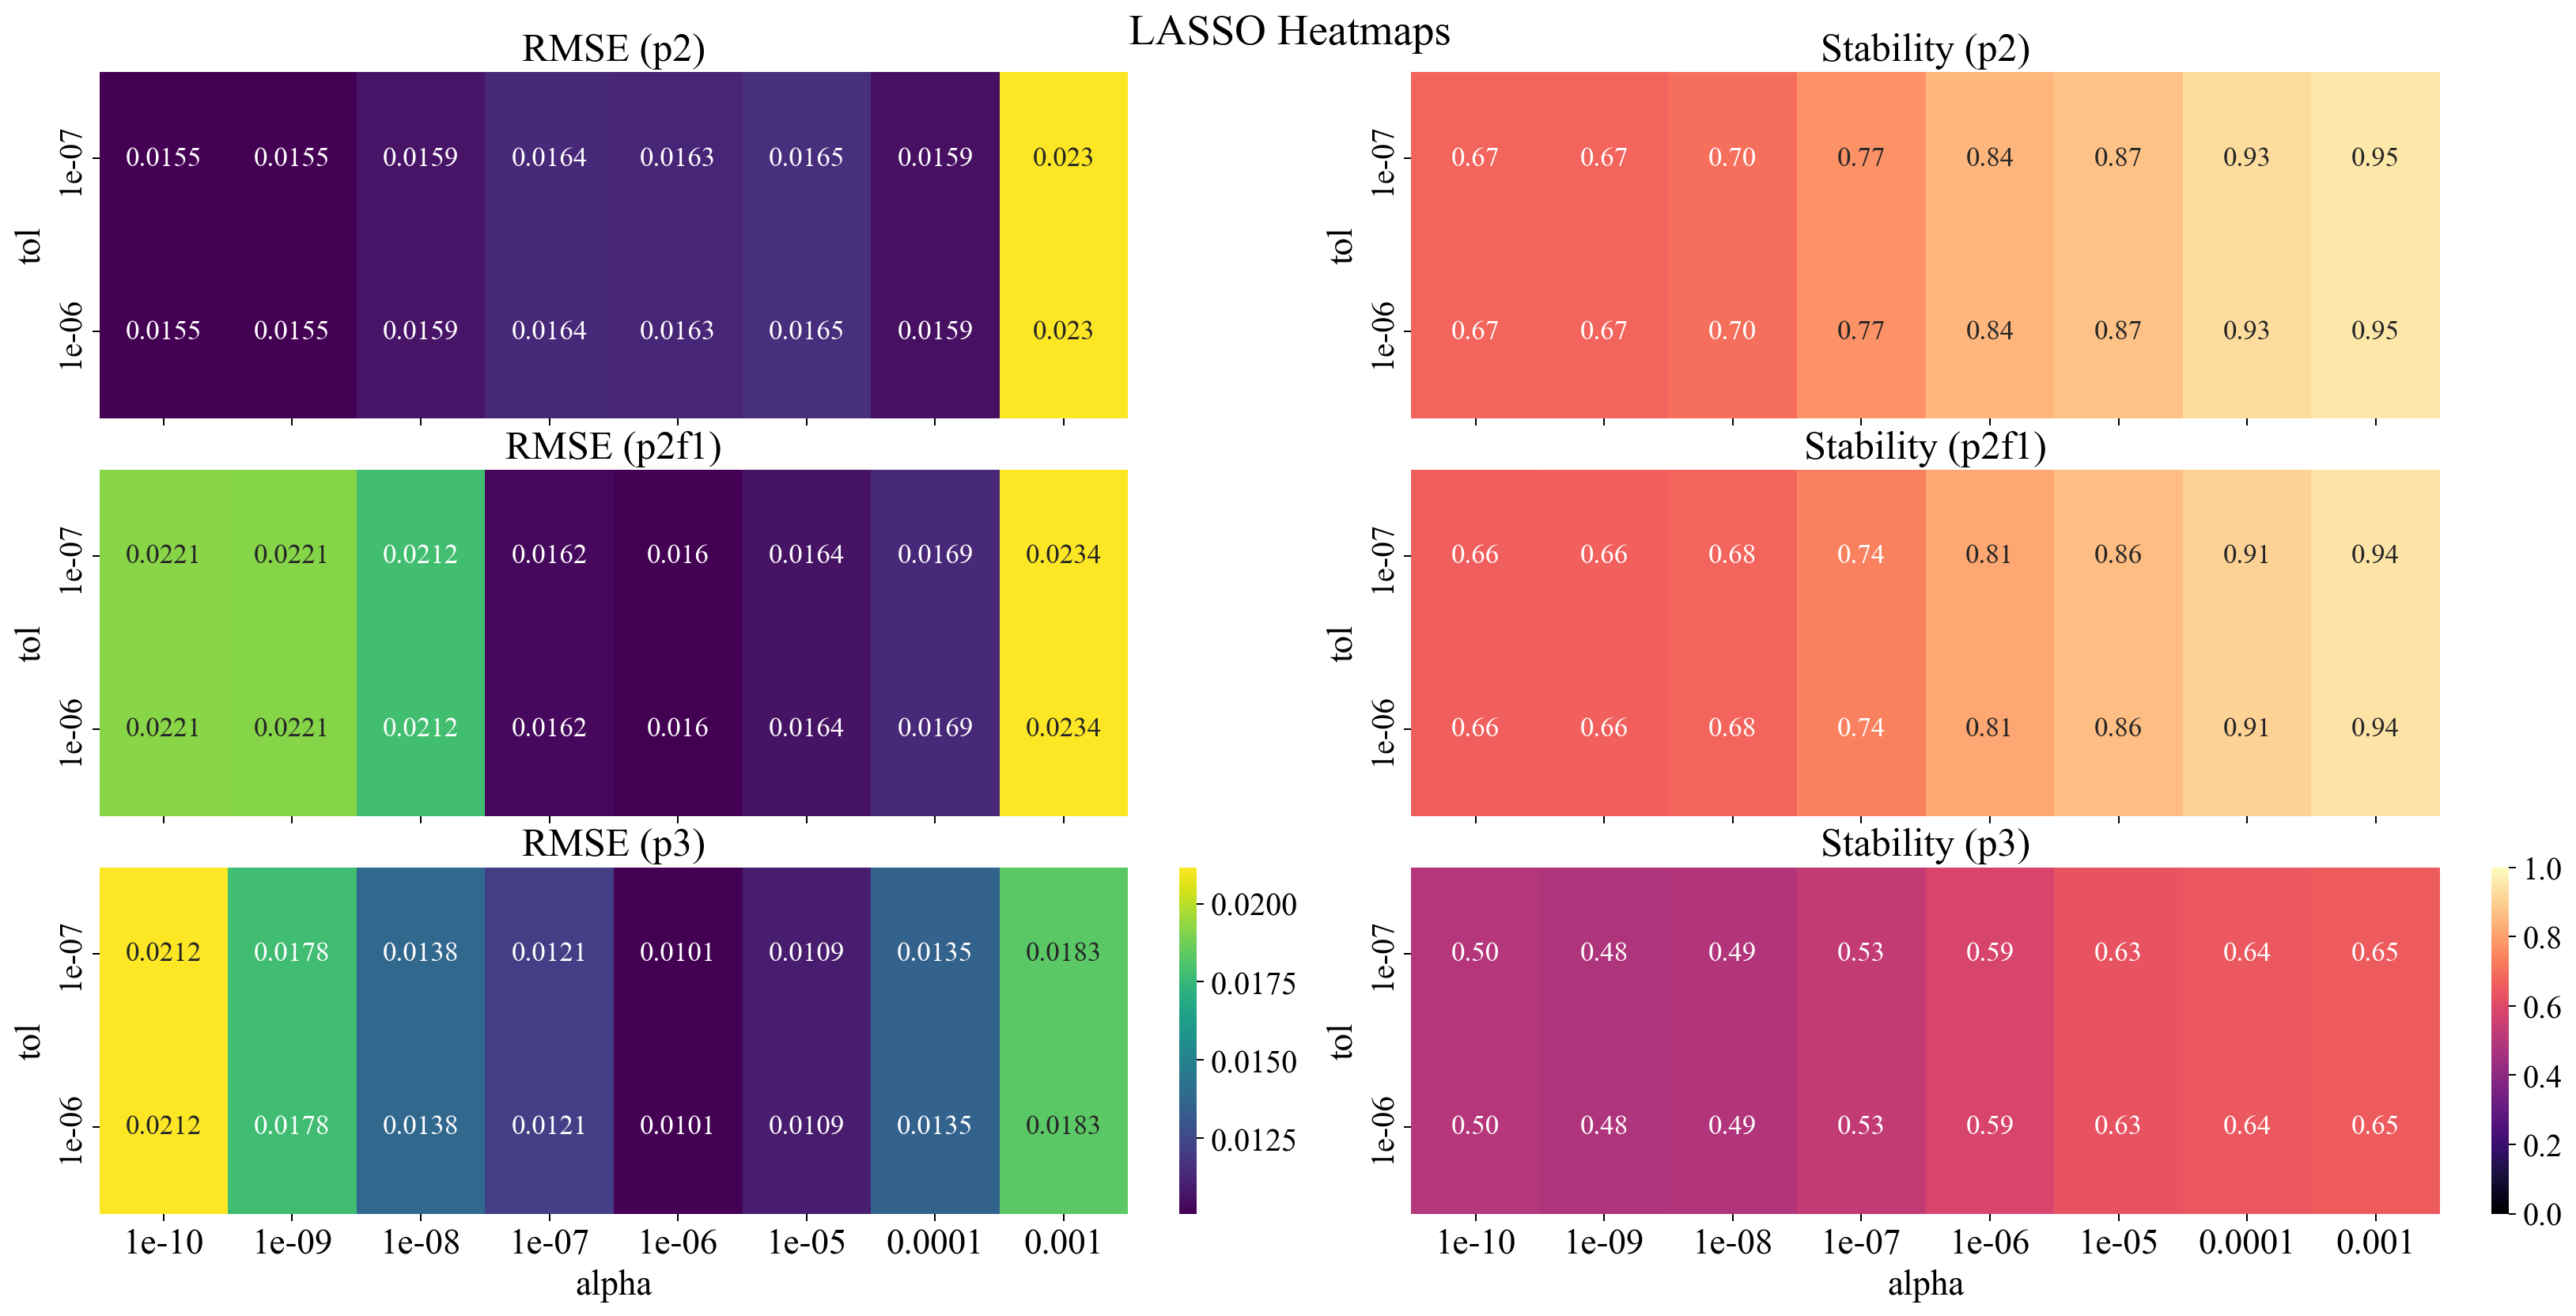

In [9]:
# 5a) Stack RunTags in one figure (fixed: BOTH RMSE + Stability, 3x2)

def plot_heatmap_stack_both(summary_df, opt_group="Lasso", tags=None):
    if tags is None:
        tags = ["n2", "n2withfourier1", "n3"]

    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 16,
    })

    opt_base = "SR3" if str(opt_group).startswith("SR3") else str(opt_group)
    if opt_base not in _regex_map:
        raise ValueError(f"Unsupported opt_group: {opt_group!r}")

    re1, re2, x_name, y_name = _regex_map[opt_base]

    nrows = len(tags)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=2,
        figsize=(18, 3 * nrows),
        constrained_layout=True,
    )

    if nrows == 1:
        axes = np.array([axes])

    for i, run_tag in enumerate(tags):
        display_tag = _RUN_TAG_LABELS.get(run_tag, run_tag)
        is_bottom = i == (nrows - 1)

        hm = summary_df.copy()
        configs = hm["Config"].astype(str)
        hm["p1"] = configs.str.extract(re1)["p1"].map(_to_float_safe)
        hm["p2"] = configs.str.extract(re2)["p2"].map(_to_float_safe)
        hm = hm[(hm["RunTag"] == run_tag) & (hm["OptimizerGroup"] == opt_group)].dropna(
            subset=["p1", "p2", "Mean_RMSE_Stable"]
        )

        ax_rmse, ax_stab = axes[i, 0], axes[i, 1]
        if hm.empty:
            ax_rmse.axis("off")
            ax_stab.axis("off")
            ax_rmse.text(0.5, 0.5, f"No data: {display_tag}", ha="center", va="center")
            continue

        agg = hm.groupby(["p1", "p2"], as_index=False).agg(
            Mean_RMSE_Stable=("Mean_RMSE_Stable", "min"),
            Stability_Fraction=("Stability_Fraction", "mean"),
        )

        x_sorted = sorted(agg["p1"].unique())
        y_sorted = sorted(agg["p2"].unique())
        grid_rmse = agg.pivot(index="p2", columns="p1", values="Mean_RMSE_Stable").reindex(
            index=y_sorted, columns=x_sorted
        )
        grid_stab = agg.pivot(index="p2", columns="p1", values="Stability_Fraction").reindex(
            index=y_sorted, columns=x_sorted
        )

        do_annot = grid_rmse.shape[0] * grid_rmse.shape[1] <= 300

        sns.heatmap(
            grid_rmse,
            ax=ax_rmse,
            cmap="viridis",
            annot=do_annot,
            fmt=".3g",
            annot_kws={"size": 14},
            #linewidths=0.3,
            linecolor="white",
            cbar=is_bottom,
            #cbar_kws={"label": "RMSE", "shrink": 0.9},
            mask=grid_rmse.isna(),
        )
        ax_rmse.set_title(f"RMSE ({display_tag})")
        ax_rmse.set_xlabel(x_name if is_bottom else "")
        if not is_bottom:
            ax_rmse.tick_params(axis="x", labelbottom=False)
        ax_rmse.set_ylabel(y_name)

        sns.heatmap(
            grid_stab,
            ax=ax_stab,
            cmap="magma",
            vmin=0,
            vmax=1,
            annot=do_annot,
            fmt=".2f",
            annot_kws={"size": 14},
            linecolor="white",
            cbar=is_bottom,
            #cbar_kws={"label": "Stability", "shrink": 0.9},
            mask=grid_stab.isna(),
        )
        ax_stab.set_title(f"Stability ({display_tag})")
        ax_stab.set_xlabel(x_name if is_bottom else "")
        if not is_bottom:
            ax_stab.tick_params(axis="x", labelbottom=False)
        ax_stab.set_ylabel(y_name)

    fig.suptitle("LASSO Heatmaps", fontsize=22, y=1.01)
    #plt.show()


# Run: fixed BOTH view (3x2)
plot_heatmap_stack_both(
    summary_adv,
    opt_group="Lasso",
    tags=["n2", "n2withfourier1", "n3"],
)

#save the figure as pdf
out_pdf = BASE_DIR / "heatmap_stack_lasso.pdf"
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")

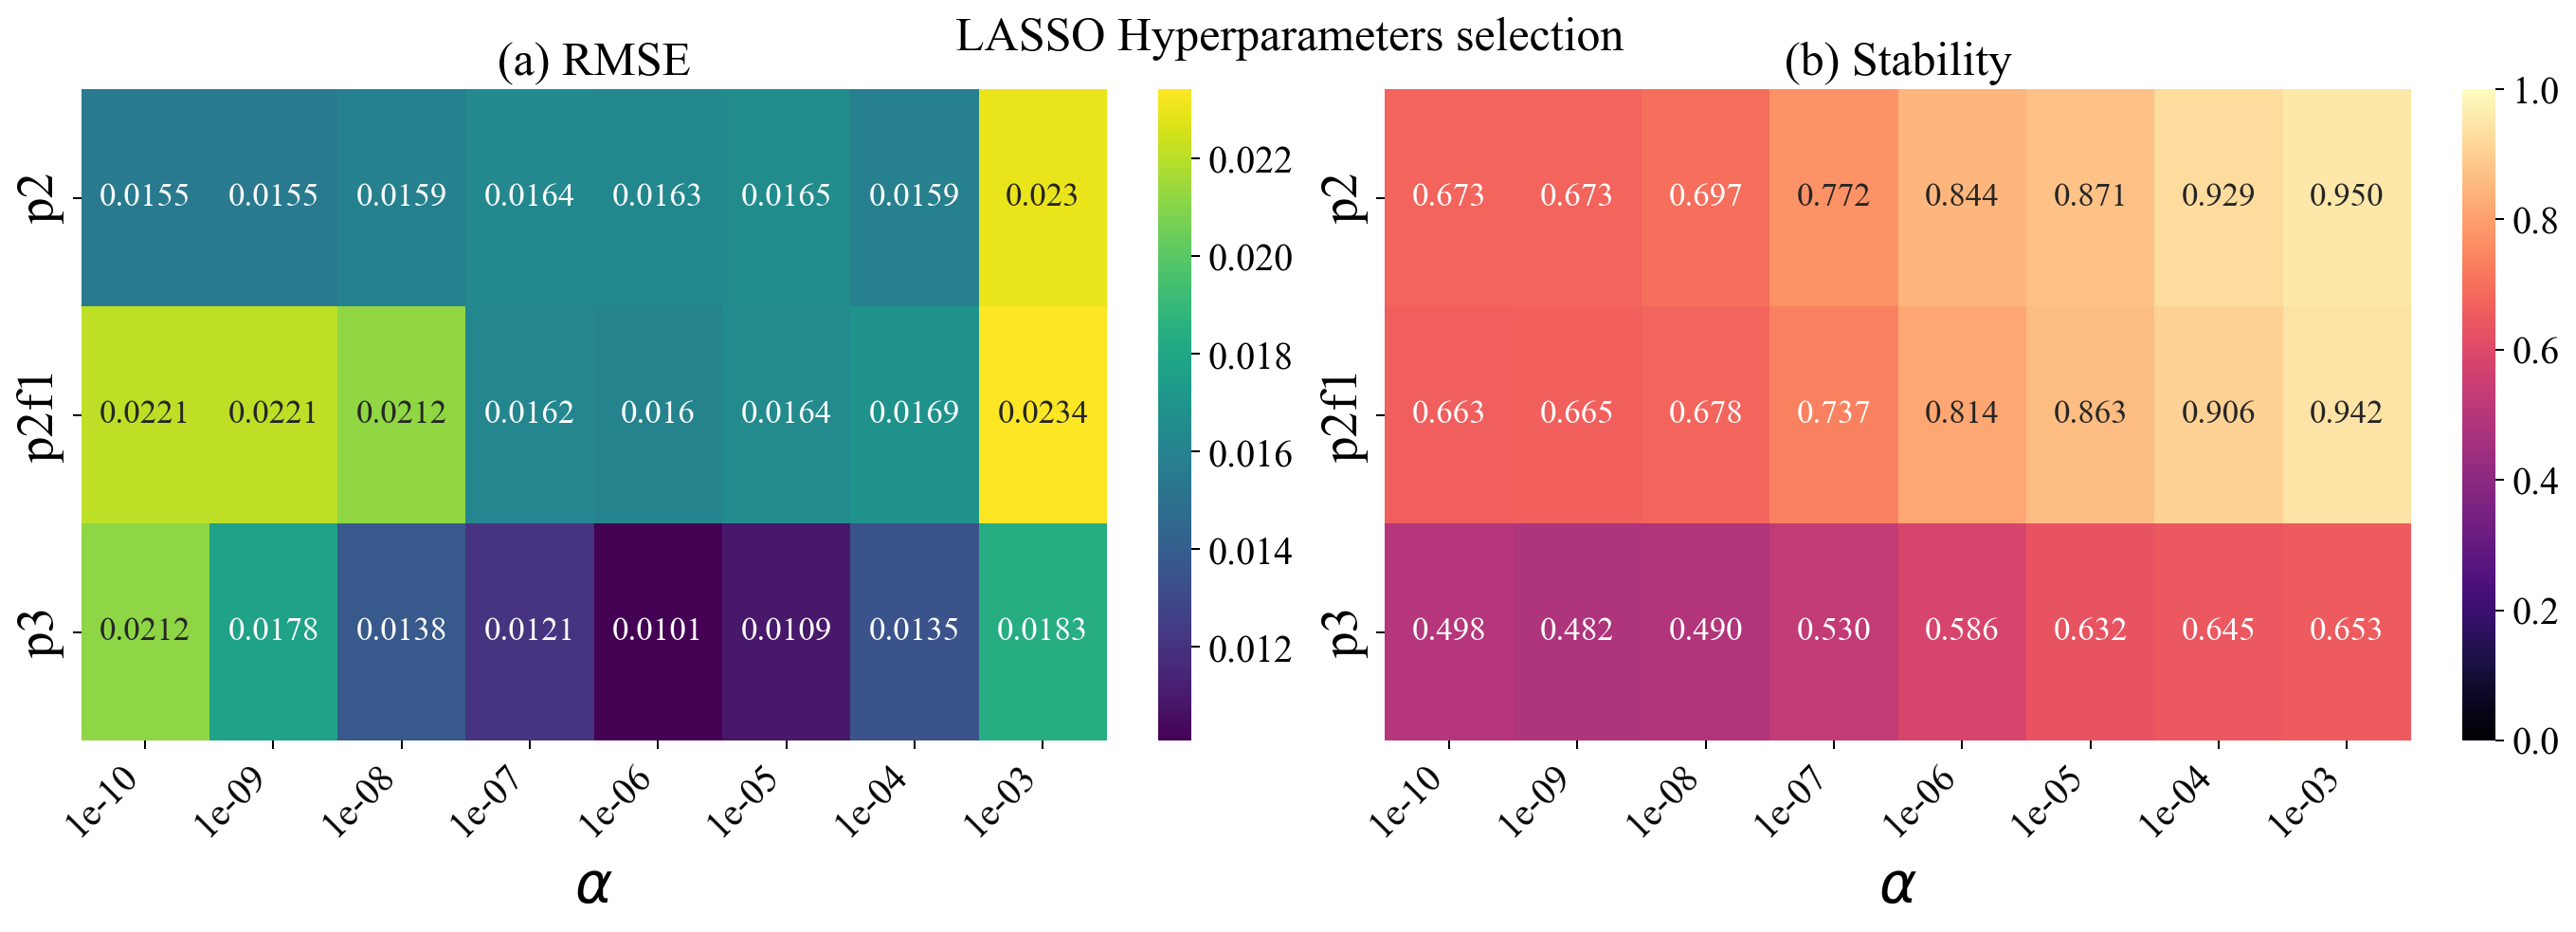

In [ ]:
# 5b) Lasso alpha-only heatmaps in ONE figure (1x2): left RMSE, right Stability
# alpha on x-axis with unified scientific notation

_ALPHA_RE = rf"(?:^|_)alpha_(?P<alpha>{_num_pat})(?:_|$)"


def plot_lasso_alpha_combined_both(summary_df, tags=None):
    if tags is None:
        tags = ["n2", "n2withfourier1", "n3"]

    alpha_label_fs = 24
    y_tick_fs = 22

    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    })

    hm = summary_df.copy()
    configs = hm["Config"].astype(str)
    hm["alpha"] = configs.str.extract(_ALPHA_RE)["alpha"].map(_to_float_safe)
    hm = hm[(hm["OptimizerGroup"] == "Lasso") & (hm["RunTag"].isin(tags))].dropna(
        subset=["alpha", "Mean_RMSE_Stable", "Stability_Fraction"]
    )

    if hm.empty:
        print("[warn] No Lasso alpha-only rows found.")
        return

    # Aggregate over possible duplicate entries per (RunTag, alpha)
    agg = hm.groupby(["RunTag", "alpha"], as_index=False).agg(
        Mean_RMSE_Stable=("Mean_RMSE_Stable", "min"),
        Stability_Fraction=("Stability_Fraction", "mean"),
    )

    # Map tags to display labels and keep requested row order
    tag_to_label = {t: _RUN_TAG_LABELS.get(t, t) for t in tags}
    agg["TagLabel"] = agg["RunTag"].map(tag_to_label)

    alpha_sorted = sorted(agg["alpha"].unique())
    alpha_labels = [f"{a:.0e}" for a in alpha_sorted]
    row_order = [tag_to_label[t] for t in tags]

    grid_rmse = agg.pivot(index="TagLabel", columns="alpha", values="Mean_RMSE_Stable").reindex(
        index=row_order, columns=alpha_sorted
    )
    grid_stab = agg.pivot(index="TagLabel", columns="alpha", values="Stability_Fraction").reindex(
        index=row_order, columns=alpha_sorted
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), constrained_layout=True)

    sns.heatmap(
        grid_rmse,
        ax=axes[0],
        cmap="viridis",
        annot=True,
        fmt=".3g",
        annot_kws={"size": 14},
        #linewidths=0.3,
        #linecolor="white",
        cbar=True,
        #cbar_kws={"label": "Mean_RMSE_Stable", "shrink": 0.9},
        mask=grid_rmse.isna(),
    )
    axes[0].set_title("(a) RMSE")
    axes[0].set_xlabel(r"$\alpha$", fontsize=alpha_label_fs, labelpad=8)
    axes[0].set_ylabel("")
    axes[0].set_xticks(np.arange(len(alpha_labels)) + 0.5)
    axes[0].set_xticklabels(alpha_labels, rotation=45, ha="right")
    axes[0].tick_params(axis="y", labelsize=y_tick_fs)

    sns.heatmap(
        grid_stab,
        ax=axes[1],
        cmap="magma",
        vmin=0,
        vmax=1,
        annot=True,
        fmt=".3f",
        annot_kws={"size": 14},
        #linewidths=0.3,
        #linecolor="white",
        cbar=True,
        #cbar_kws={"label": "Stability_Fraction", "shrink": 0.9},
        mask=grid_stab.isna(),
    )
    axes[1].set_title("(b) Stability")
    axes[1].set_xlabel(r"$\alpha$", fontsize=alpha_label_fs, labelpad=8)
    axes[1].set_ylabel("")
    axes[1].set_xticks(np.arange(len(alpha_labels)) + 0.5)
    axes[1].set_xticklabels(alpha_labels, rotation=45, ha="right")
    axes[1].tick_params(axis="y", labelsize=y_tick_fs)

    fig.suptitle("LASSO Hyperparameters selection", fontsize=20, y=1.02)
    #plt.show()


# Run: one figure with 1x2 panels, alpha on x-axis
plot_lasso_alpha_combined_both(
    summary_adv,
    tags=["n2", "n2withfourier1", "n3"],
)

# Optional save
out_pdf = BASE_DIR / "heatmap_lasso_alpha.pdf"
plt.savefig(out_pdf, format="pdf", bbox_inches="tight")

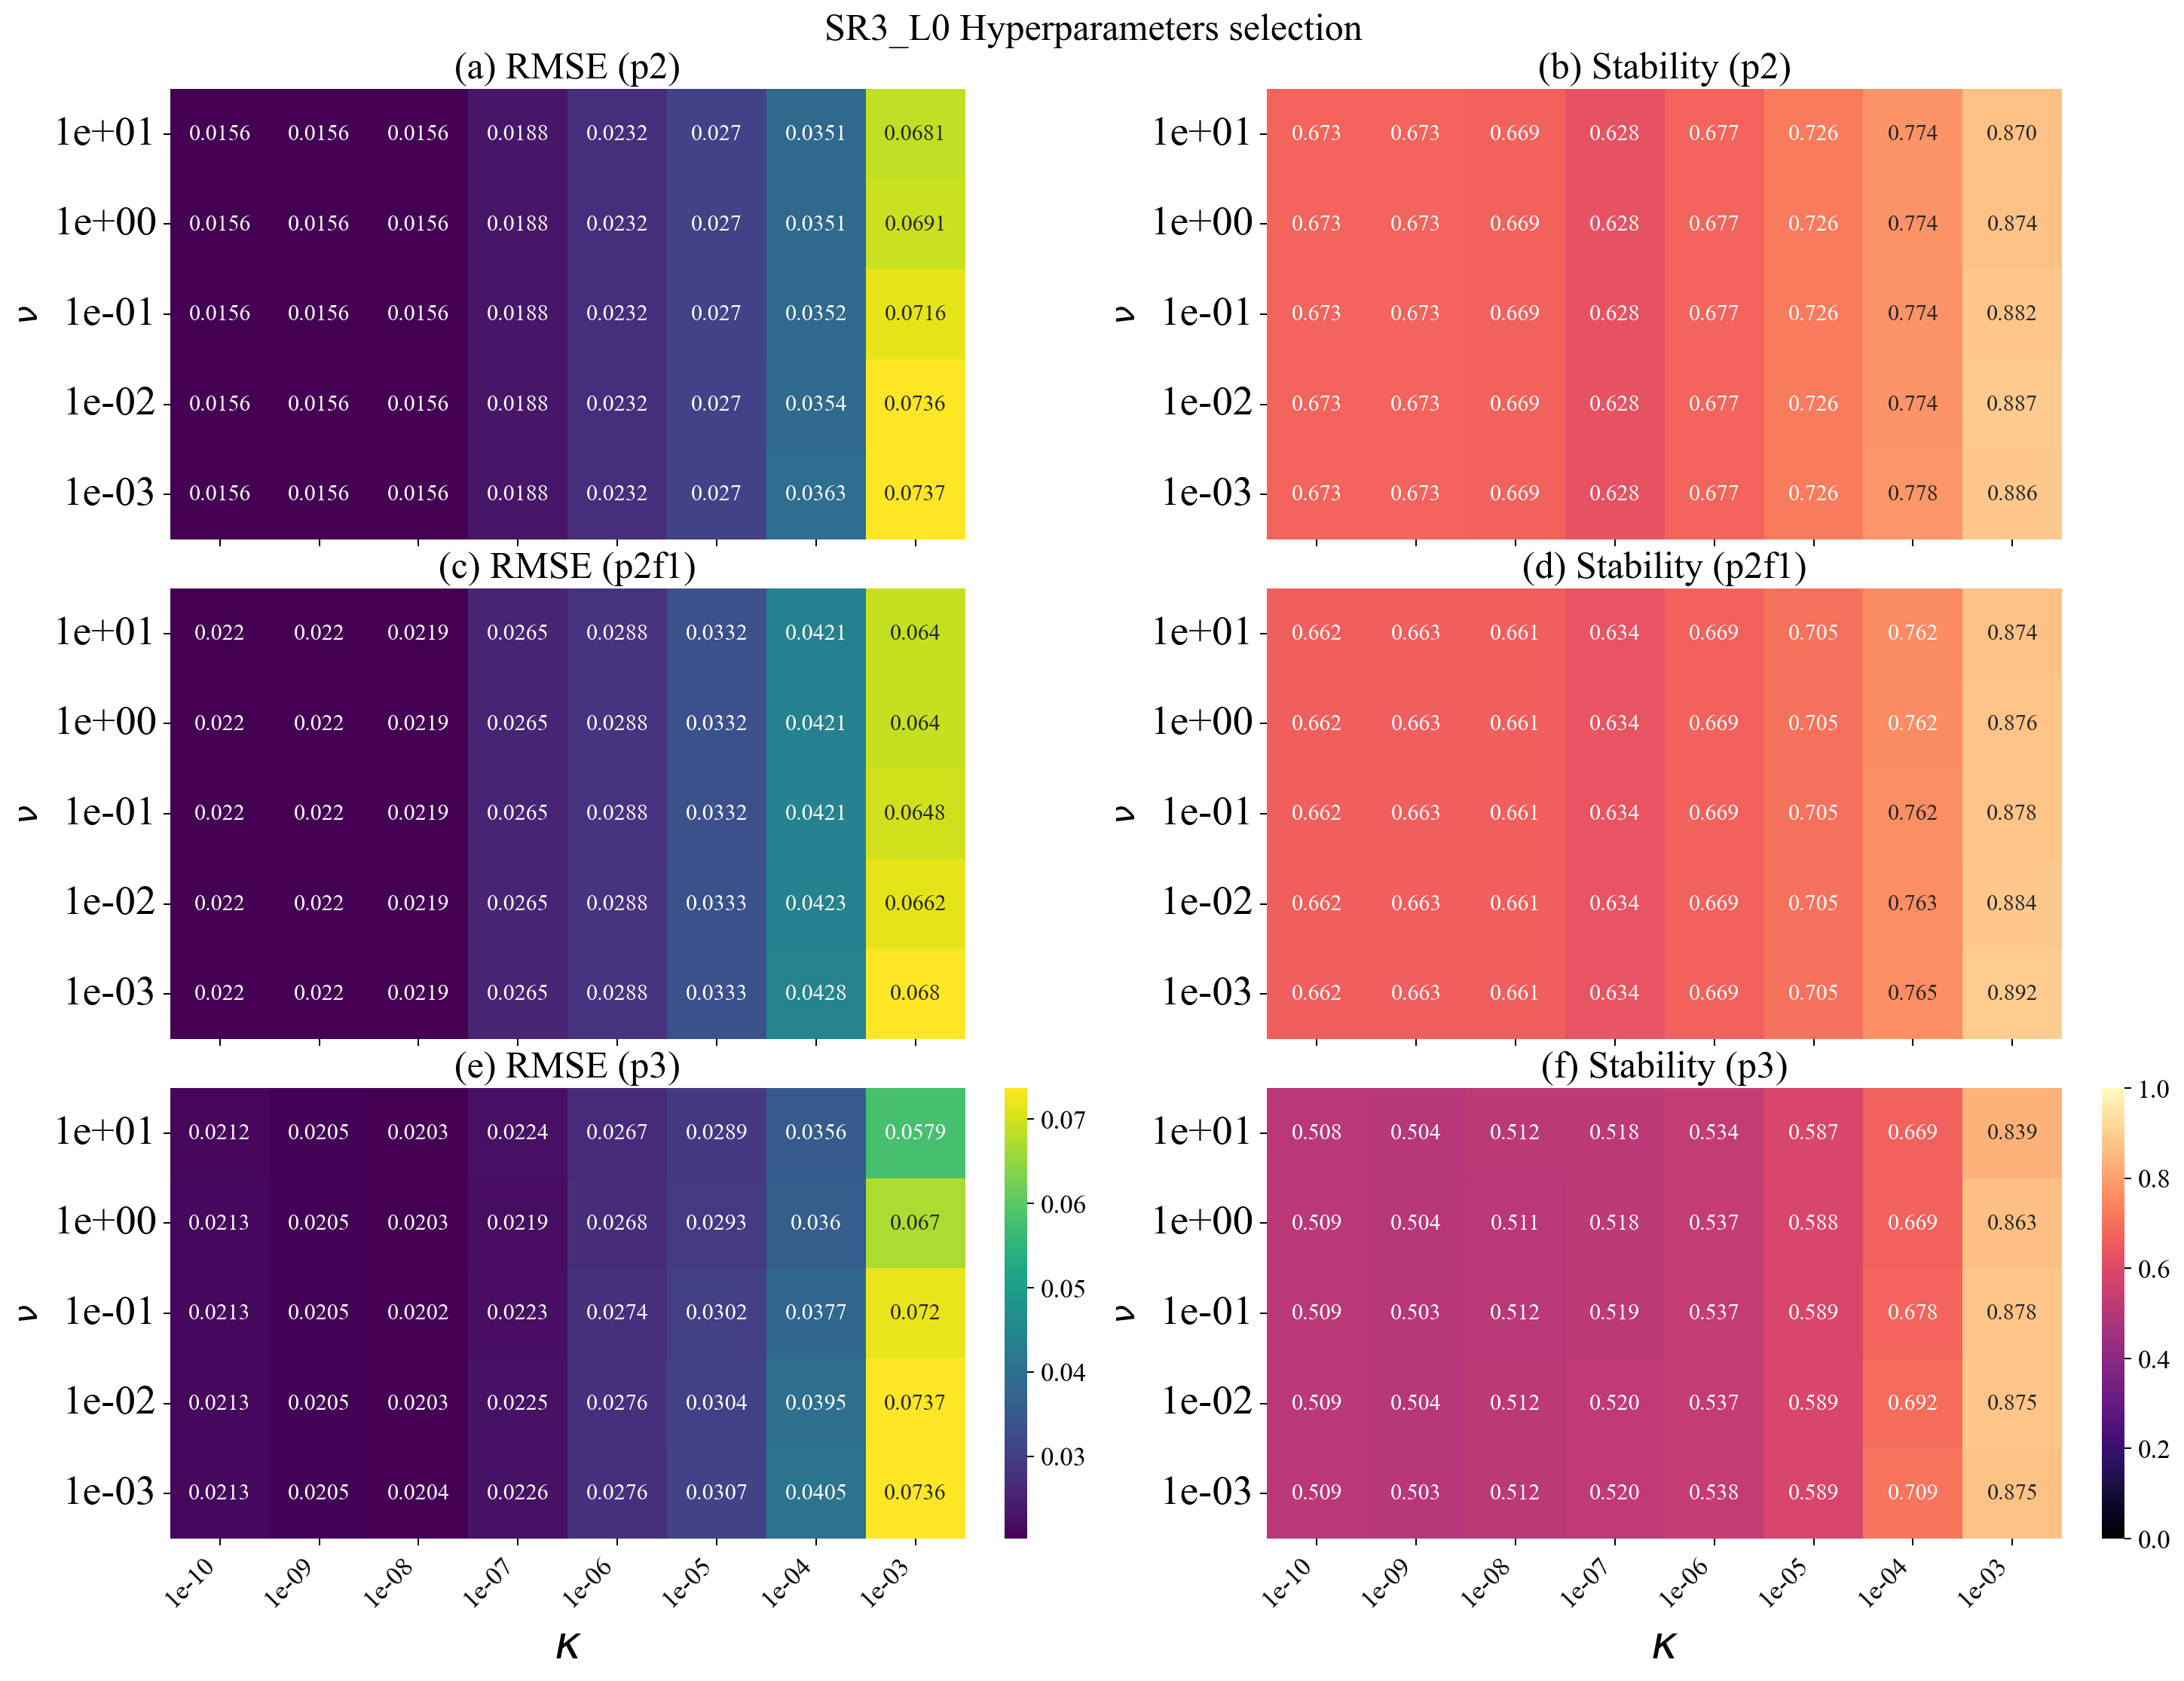

In [56]:
# 5c) SR3_l0 heatmaps with BOTH nu and thr (3x2)
# rows: p2 / p2f1 / p3, columns: RMSE / Stability
# axis mapping: y = nu, x = kappa(thr)

_NU_RE = rf"(?:^|_)nu_(?P<nu>{_num_pat})(?:_|$)"
_THR_RE = rf"(?:^|_)thr_(?P<thr>{_num_pat})(?:_|$)"


def plot_sr3_l0_nu_thr_stack_both(summary_df, tags=None, nu_descending=True):
    if tags is None:
        tags = ["n2", "n2withfourier1", "n3"]

    x_label_fs = 24
    y_tick_fs = 22

    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    })

    nrows = len(tags)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=2,
        figsize=(16, 4 * nrows),
        constrained_layout=True,
    )

    if nrows == 1:
        axes = np.array([axes])

    # Panel labels
    panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
    label_idx = 0

    for i, run_tag in enumerate(tags):
        display_tag = _RUN_TAG_LABELS.get(run_tag, run_tag)
        is_bottom = i == (nrows - 1)

        hm = summary_df.copy()
        configs = hm["Config"].astype(str)
        hm["nu"] = configs.str.extract(_NU_RE)["nu"].map(_to_float_safe)
        hm["thr"] = configs.str.extract(_THR_RE)["thr"].map(_to_float_safe)
        hm = hm[(hm["OptimizerGroup"] == "SR3_l0") & (hm["RunTag"] == run_tag)].dropna(
            subset=["nu", "thr", "Mean_RMSE_Stable", "Stability_Fraction"]
        )

        ax_rmse, ax_stab = axes[i, 0], axes[i, 1]

        if hm.empty:
            ax_rmse.axis("off")
            ax_stab.axis("off")
            ax_rmse.text(0.5, 0.5, f"No data: {display_tag}", ha="center", va="center")
            continue

        agg = hm.groupby(["nu", "thr"], as_index=False).agg(
            Mean_RMSE_Stable=("Mean_RMSE_Stable", "min"),
            Stability_Fraction=("Stability_Fraction", "mean"),
        )

        nu_sorted = sorted(agg["nu"].unique(), reverse=nu_descending)
        thr_sorted = sorted(agg["thr"].unique())
        nu_labels = [f"{x:.0e}" for x in nu_sorted]
        thr_labels = [f"{x:.0e}" for x in thr_sorted]

        # y = nu, x = kappa(thr)
        grid_rmse = agg.pivot(index="nu", columns="thr", values="Mean_RMSE_Stable").reindex(
            index=nu_sorted, columns=thr_sorted
        )
        grid_stab = agg.pivot(index="nu", columns="thr", values="Stability_Fraction").reindex(
            index=nu_sorted, columns=thr_sorted
        )

        do_annot = grid_rmse.shape[0] * grid_rmse.shape[1] <= 300

        sns.heatmap(
            grid_rmse,
            ax=ax_rmse,
            cmap="viridis",
            annot=do_annot,
            fmt=".3g",
            annot_kws={"size": 12},
            cbar=is_bottom,
            #cbar_kws={"label": "Mean_RMSE_Stable", "shrink": 0.9} if is_bottom else None,
            mask=grid_rmse.isna(),
        )
        ax_rmse.set_title(f"{panel_labels[label_idx]} RMSE ({display_tag})")
        ax_rmse.set_xlabel(r"$\kappa$" if is_bottom else "", fontsize=x_label_fs if is_bottom else None, labelpad=8)
        if not is_bottom:
            ax_rmse.tick_params(axis="x", labelbottom=False)
        else:
            ax_rmse.set_xticks(np.arange(len(thr_labels)) + 0.5)
            ax_rmse.set_xticklabels(thr_labels, rotation=45, ha="right")
        ax_rmse.set_yticks(np.arange(len(nu_labels)) + 0.5)
        ax_rmse.set_yticklabels(nu_labels, rotation=0)
        ax_rmse.set_ylabel(r"$\nu$")
        ax_rmse.tick_params(axis="y", labelsize=y_tick_fs)

        sns.heatmap(
            grid_stab,
            ax=ax_stab,
            cmap="magma",
            vmin=0,
            vmax=1,
            annot=do_annot,
            fmt=".3f",
            annot_kws={"size": 12},
            cbar=is_bottom,
            #cbar_kws={"label": "Stability_Fraction", "shrink": 0.9} if is_bottom else None,
            mask=grid_stab.isna(),
        )
        ax_stab.set_title(f"{panel_labels[label_idx + 1]} Stability ({display_tag})")
        ax_stab.set_xlabel(r"$\kappa$" if is_bottom else "", fontsize=x_label_fs if is_bottom else None, labelpad=8)
        if not is_bottom:
            ax_stab.tick_params(axis="x", labelbottom=False)
        else:
            ax_stab.set_xticks(np.arange(len(thr_labels)) + 0.5)
            ax_stab.set_xticklabels(thr_labels, rotation=45, ha="right")
        ax_stab.set_yticks(np.arange(len(nu_labels)) + 0.5)
        ax_stab.set_yticklabels(nu_labels, rotation=0)
        ax_stab.set_ylabel(r"$\nu$")
        ax_stab.tick_params(axis="y", labelsize=y_tick_fs)

        label_idx += 2

    fig.suptitle("SR3_L0 Hyperparameters selection", fontsize=20, y=1.02)


# Run: SR3_l0 heatmaps with nu+thr (3x2)
plot_sr3_l0_nu_thr_stack_both(
    summary_adv,
    tags=["n2", "n2withfourier1", "n3"],
)

# Optional save
out_pdf_sr3_l0 = BASE_DIR / "heatmap_sr3_l0.pdf"
plt.savefig(out_pdf_sr3_l0, format="pdf", bbox_inches="tight")

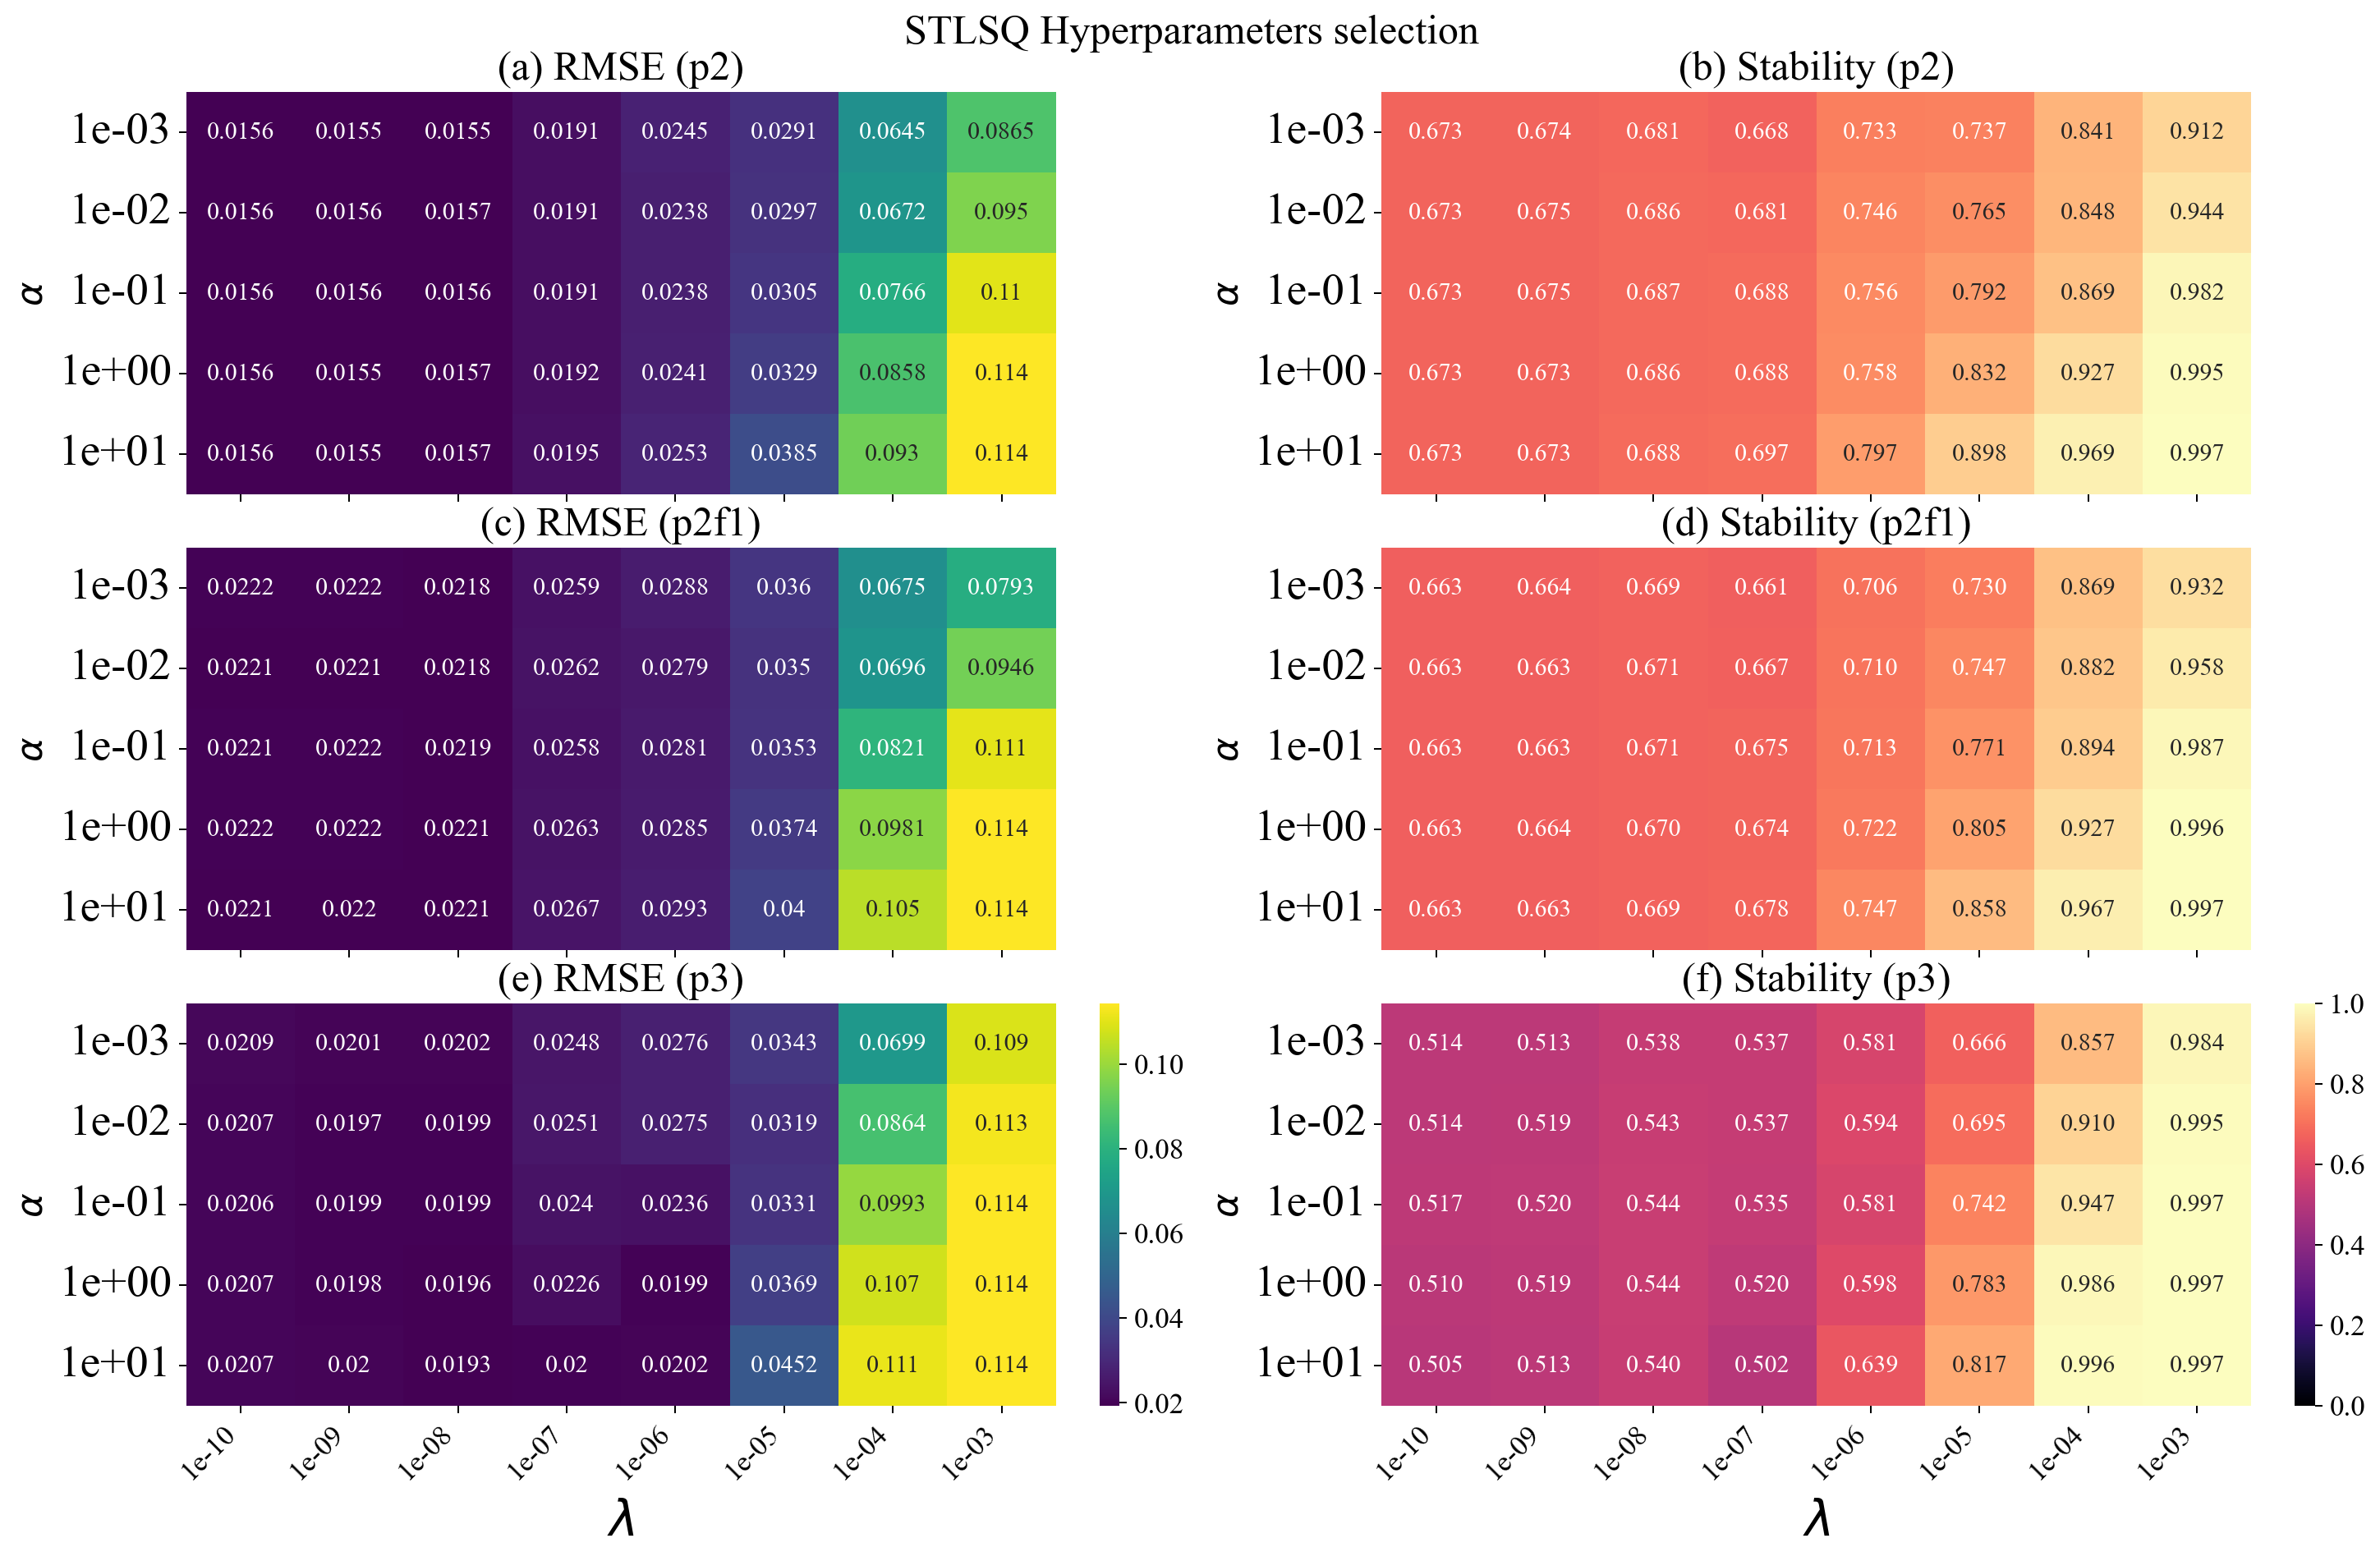

In [59]:
# 5d) STLSQ heatmaps with thr and alpha (3x2)
# rows: p2 / p2f1 / p3, columns: RMSE / Stability
# axis mapping: y = alpha, x = thr

_THR_RE = rf"(?:^|_)thr_(?P<thr>{_num_pat})(?:_|$)"
_ALPHA_STLSQ_RE = rf"(?:^|_)alpha_(?P<alpha>{_num_pat})(?:_|$)"


def plot_stlsq_thr_alpha_stack_both(summary_df, tags=None, alpha_descending=False):
    if tags is None:
        tags = ["n2", "n2withfourier1", "n3"]

    x_label_fs = 24
    y_tick_fs = 22

    plt.rcParams.update({
        "font.family": "Times New Roman",
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
    })

    nrows = len(tags)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=2,
        figsize=(16, 3.4 * nrows),
        constrained_layout=True,
    )

    if nrows == 1:
        axes = np.array([axes])

    # Panel labels
    panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
    label_idx = 0

    for i, run_tag in enumerate(tags):
        display_tag = _RUN_TAG_LABELS.get(run_tag, run_tag)
        is_bottom = i == (nrows - 1)

        hm = summary_df.copy()
        configs = hm["Config"].astype(str)
        hm["thr"] = configs.str.extract(_THR_RE)["thr"].map(_to_float_safe)
        hm["alpha"] = configs.str.extract(_ALPHA_STLSQ_RE)["alpha"].map(_to_float_safe)
        hm = hm[(hm["OptimizerGroup"] == "STLSQ") & (hm["RunTag"] == run_tag)].dropna(
            subset=["thr", "alpha", "Mean_RMSE_Stable", "Stability_Fraction"]
        )

        ax_rmse, ax_stab = axes[i, 0], axes[i, 1]

        if hm.empty:
            ax_rmse.axis("off")
            ax_stab.axis("off")
            ax_rmse.text(0.5, 0.5, f"No data: {display_tag}", ha="center", va="center")
            continue

        agg = hm.groupby(["thr", "alpha"], as_index=False).agg(
            Mean_RMSE_Stable=("Mean_RMSE_Stable", "min"),
            Stability_Fraction=("Stability_Fraction", "mean"),
        )

        thr_sorted = sorted(agg["thr"].unique())
        alpha_sorted = sorted(agg["alpha"].unique(), reverse=alpha_descending)
        thr_labels = [f"{x:.0e}" for x in thr_sorted]
        alpha_labels = [f"{x:.0e}" for x in alpha_sorted]

        # y = alpha, x = thr
        grid_rmse = agg.pivot(index="alpha", columns="thr", values="Mean_RMSE_Stable").reindex(
            index=alpha_sorted, columns=thr_sorted
        )
        grid_stab = agg.pivot(index="alpha", columns="thr", values="Stability_Fraction").reindex(
            index=alpha_sorted, columns=thr_sorted
        )

        do_annot = grid_rmse.shape[0] * grid_rmse.shape[1] <= 300

        sns.heatmap(
            grid_rmse,
            ax=ax_rmse,
            cmap="viridis",
            annot=do_annot,
            fmt=".3g",
            annot_kws={"size": 12},
            cbar=is_bottom,
            mask=grid_rmse.isna(),
        )
        ax_rmse.set_title(f"{panel_labels[label_idx]} RMSE ({display_tag})")
        ax_rmse.set_xlabel(r"$\lambda$" if is_bottom else "", fontsize=x_label_fs if is_bottom else None, labelpad=8)
        if not is_bottom:
            ax_rmse.tick_params(axis="x", labelbottom=False)
        else:
            ax_rmse.set_xticks(np.arange(len(thr_labels)) + 0.5)
            ax_rmse.set_xticklabels(thr_labels, rotation=45, ha="right")
        ax_rmse.set_yticks(np.arange(len(alpha_labels)) + 0.5)
        ax_rmse.set_yticklabels(alpha_labels, rotation=0)
        ax_rmse.set_ylabel(r"$\alpha$", fontfamily="DejaVu Sans")
        ax_rmse.tick_params(axis="y", labelsize=y_tick_fs)

        sns.heatmap(
            grid_stab,
            ax=ax_stab,
            cmap="magma",
            vmin=0,
            vmax=1,
            annot=do_annot,
            fmt=".3f",
            annot_kws={"size": 12},
            cbar=is_bottom,
            mask=grid_stab.isna(),
        )
        ax_stab.set_title(f"{panel_labels[label_idx + 1]} Stability ({display_tag})")
        ax_stab.set_xlabel(r"$\lambda$" if is_bottom else "", fontsize=x_label_fs if is_bottom else None, labelpad=8)
        if not is_bottom:
            ax_stab.tick_params(axis="x", labelbottom=False)
        else:
            ax_stab.set_xticks(np.arange(len(thr_labels)) + 0.5)
            ax_stab.set_xticklabels(thr_labels, rotation=45, ha="right")
        ax_stab.set_yticks(np.arange(len(alpha_labels)) + 0.5)
        ax_stab.set_yticklabels(alpha_labels, rotation=0)
        ax_stab.set_ylabel(r"$\alpha$", fontfamily="DejaVu Sans")
        ax_stab.tick_params(axis="y", labelsize=y_tick_fs)

        label_idx += 2

    fig.suptitle("STLSQ Hyperparameters selection", fontsize=20, y=1.02)


# Run: STLSQ heatmaps with thr+alpha (3x2)
plot_stlsq_thr_alpha_stack_both(
    summary_adv,
    tags=["n2", "n2withfourier1", "n3"],
)

# Optional save
out_pdf_stlsq = BASE_DIR / "heatmap_stlsq.pdf"
plt.savefig(out_pdf_stlsq, format="pdf", bbox_inches="tight")